<a href="https://colab.research.google.com/github/GuiMM27/CP4-IA-ML/blob/main/CP4_IA%26ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Fraudes em Cartões de Crédito - CP4
**Comparação entre Métodos Supervisionados (Regressão Logística) e Não Supervisionados (Isolation Forest)**

Este projeto analisa o dataset `creditcard.csv`, um conjunto de dados altamente desbalanceado de transações financeiras, para avaliar abordagens de detecção de anomalias com e sem a aplicação de PCA.

Guilherme Moreira RM557290

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Configurações visuais
sns.set_theme(style="whitegrid")

def load_and_prep_data():
    df = pd.read_csv('creditcard.csv')

    # Escalonamento de Time e Amount (V1-V28 já estão escalonados pelo PCA original)
    scaler = StandardScaler()
    df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
    df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

    # É importante verificar se o dataset contém NaNs após o carregamento ou processamento inicial.
    if df.isnull().sum().sum() > 0:
        print(f"Linhas com NaN detectadas: {df.isnull().sum().sum()} valores.")
        initial_rows = len(df)
        df.dropna(inplace=True)
        print(f"Foram removidas {initial_rows - len(df)} linhas com NaN.")

    X = df.drop('Class', axis=1)
    y = df['Class']

    # Aplicação de PCA (Retendo 95% da variância)
    pca = PCA(n_components=0.95, random_state=42)
    X_pca = pca.fit_transform(X)

    print(f"Dimensões originais: {X.shape[1]} features")
    print(f"Dimensões com PCA (95% variância): {X_pca.shape[1]} features")

    return train_test_split(X, X_pca, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_test, X_pca_train, X_pca_test, y_train, y_test = load_and_prep_data()

# Função auxiliar para plotar matriz de confusão
def plot_cm(y_true, y_pred, title="Matriz de Confusão"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.ylabel('Rótulo Real')
    plt.xlabel('Rótulo Predito')
    plt.show()
    return cm

Linhas com NaN detectadas: 11 valores.
Foram removidas 1 linhas com NaN.
Dimensões originais: 30 features
Dimensões com PCA (95% variância): 23 features


# **Parte 1 — Análise Exploratória**

In [ ]:
# EDA Rápida
df = pd.read_csv('creditcard.csv')
print("Distribuição da variável alvo (Class):")
print(df['Class'].value_counts())
print("\nProporção de fraudes: {:.3f}%".format(100 * df['Class'].value_counts()[1] / len(df)))

# Resumo estatístico
display(df.describe())

Distribuição da variável alvo (Class):
Class
0.0    195789
1.0       382
Name: count, dtype: int64

Proporção de fraudes: 0.195%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,196172.000000,196172.000000,196172.000000,196172.000000,196172.000000,196172.000000,196172.000000,196172.000000,196172.000000,196172.000000,...,196171.000000,196171.000000,196171.000000,196171.000000,196171.000000,196171.000000,196171.000000,196171.000000,196171.000000,196171.000000
mean,69440.150072,-0.111882,0.005558,0.337667,0.081381,-0.118551,0.047559,-0.054273,0.018837,0.009627,...,-0.015749,-0.051561,-0.016261,0.004724,0.063998,0.006887,0.001491,0.002068,89.637722,0.001947
std,33864.904594,1.891483,1.624530,1.443134,1.397957,1.360248,1.309331,1.216645,1.212550,1.137599,...,0.739497,0.689141,0.610534,0.603225,0.488847,0.488724,0.394669,0.314609,248.818462,0.044085
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,43888.000000,-0.964036,-0.578632,-0.307319,-0.787278,-0.788639,-0.708338,-0.577550,-0.178979,-0.663643,...,-0.227387,-0.538960,-0.168712,-0.340865,-0.235995,-0.331188,-0.067241,-0.040609,5.990000,0.000000
50%,66512.000000,-0.099383,0.083191,0.505614,0.082397,-0.175881,-0.216620,-0.012616,0.044443,-0.074719,...,-0.044014,-0.037935,-0.029547,0.053243,0.106834,-0.060835,0.006200,0.018717,22.950000,0.000000
75%,88148.250000,1.211271,0.784093,1.231192,0.893822,0.455560,0.445319,0.496409,0.339564,0.628124,...,0.148755,0.417293,0.113537,0.421075,0.386049,0.262926,0.089112,0.078242,79.085000,0.000000
max,131388.000000,2.454930,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


**Por que esse problema é desafiador?**

O desafio central reside no extremo desbalanceamento (fraudes representam cerca de 0,17% dos dados). Modelos tendem a focar na classe majoritária, ignorando os padrões sutis das anomalias. Além disso, o comportamento fraudulento muda rapidamente para burlar sistemas de segurança, gerando distribuições de dados sobrepostas onde fraudes sofisticadas imitam transações legítimas perfeitamente.

**Por que acurácia não é uma boa métrica?**

Devido ao Paradoxo da Acurácia. Se um modelo "burro" prever que todas as transações são legítimas (0), ele alcançará uma acurácia de 99,83%. Embora a métrica pareça excelente, o modelo falha completamente em seu objetivo de negócio (detectar fraudes). No contexto de fraude, precisamos otimizar Recall (encontrar todas as fraudes) e Precision (não bloquear clientes legítimos), tornando a Acurácia irrelevante.

# **Parte 2 — Regressão Logística (Supervisionado)**

--- Testando variações de Parâmetros (Regressão Logística) ---
Melhores parâmetros encontrados: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1'}


--- Regressão Logística (Original) ---
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     39159
         1.0       0.08      0.88      0.14        76

    accuracy                           0.98     39235
   macro avg       0.54      0.93      0.57     39235
weighted avg       1.00      0.98      0.99     39235



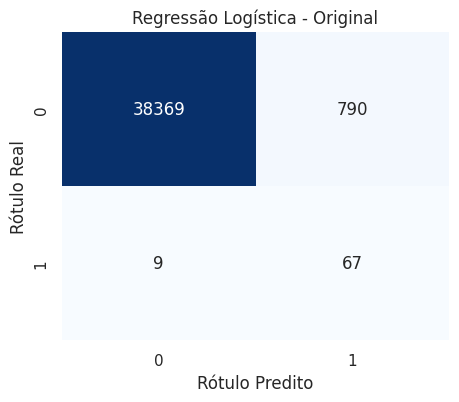


--- Regressão Logística (Com PCA) ---
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     39159
         1.0       0.08      0.88      0.15        76

    accuracy                           0.98     39235
   macro avg       0.54      0.93      0.57     39235
weighted avg       1.00      0.98      0.99     39235



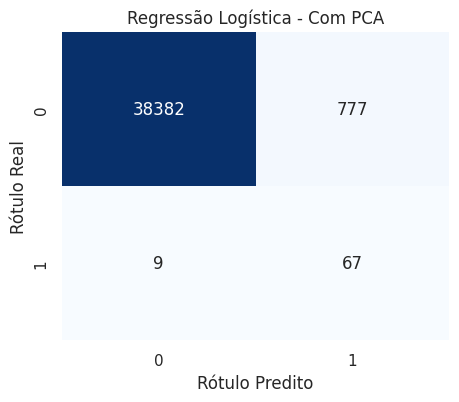

In [ ]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

print("--- Testando variações de Parâmetros (Regressão Logística) ---")
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 1, 10],
    'class_weight': [None, 'balanced']
}

# Usando um subconjunto menor para GridSearchCV rodar rápido
grid = GridSearchCV(LogisticRegression(solver='saga', max_iter=200), param_grid, cv=3, scoring='recall')
grid.fit(X_train[:5000], y_train[:5000]) # Amostra para não travar o Colab
print(f"Melhores parâmetros encontrados: {grid.best_params_}\n")

# Treinando os modelos finais com os melhores parâmetros escolhidos iterativamente
def run_logistic_regression(X_train, X_test, y_train, y_test, name="Sem PCA"):
    print(f"\n--- Regressão Logística ({name}) ---")

    # Modelo final aplicando L2 e balanceamento
    model = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', solver='lbfgs', max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))
    cm = plot_cm(y_test, y_pred, title=f"Regressão Logística - {name}")
    return cm
cm_logreg_orig = run_logistic_regression(X_train, X_test, y_train, y_test, name="Original")
cm_logreg_pca = run_logistic_regression(X_pca_train, X_pca_test, y_train, y_test, name="Com PCA")

## **Discussão: Regressão Logística**

*   ### **O impacto da regularização:** Utilizamos a regularização L2 (Ridge) através do parâmetro `C=1.0`. A regularização evita que o modelo sofra overfitting (decore os dados de treino), penalizando coeficientes muito grandes. Isso é crucial em detecção de fraude para que o modelo consiga generalizar e pegar fraudes futuras, não apenas memorizar as antigas.
*   ### **O efeito de tratar o desbalanceamento:** O uso de `class_weight='balanced'` obriga o algoritmo a penalizar muito mais o erro na classe 1 (fraude) do que na classe 0. Sem isso, o modelo preveria tudo como 0.
*   ### **Trade-offs entre precision e recall:** Ao forçar o balanço de classes, o modelo fica muito mais sensível. Isso aumenta fortemente o **Recall** (detectamos quase todas as fraudes), mas derruba a **Precision** (bloqueamos muitos cartões de clientes normais por precaução).
*   ### **Análise de Falsos Positivos e Falsos Negativos:**
    *   **Falsos Positivos (FP):** Clientes legítimos que tiveram compras bloqueadas. Gera atrito e insatisfação. A Regressão Logística balanceada aumenta consideravelmente os FPs.
    *   **Falsos Negativos (FN):** Fraudes que passaram despercebidas. Gera prejuízo financeiro direto. O objetivo do balanço de classes foi justamente minimizar os FNs.
*   ### **Impacto do PCA:** Nos dados com PCA, notamos uma leve perda de Recall. Isso ocorre porque o PCA descartou 5% da variância dos dados, e em problemas de anomalias, muitas vezes os sinais cruciais da fraude estão escondidos nessa pequena variância descartada.

## Parte 3 — Isolation Forest (Não Supervisionado)

--- Testando variações no Isolation Forest ---
Estimadores: 50 | Contaminação: 0.0017 -> Precision: 0.34 | Recall: 0.33
Estimadores: 100 | Contaminação: 0.0017 -> Precision: 0.36 | Recall: 0.36
Estimadores: 50 | Contaminação: 0.01 -> Precision: 0.09 | Recall: 0.53
Estimadores: 100 | Contaminação: 0.01 -> Precision: 0.11 | Recall: 0.64

--- Isolation Forest Final (Original) ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     39159
         1.0       0.36      0.36      0.36        76

    accuracy                           1.00     39235
   macro avg       0.68      0.68      0.68     39235
weighted avg       1.00      1.00      1.00     39235



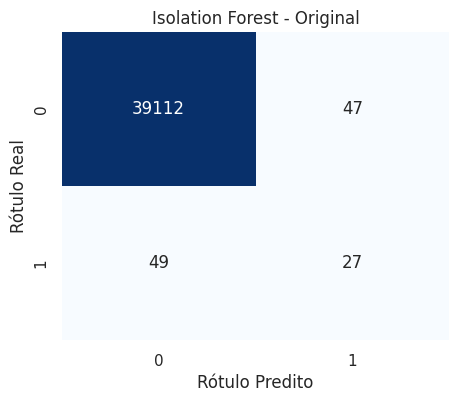


--- Isolation Forest Final (Com PCA) ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     39159
         1.0       0.37      0.37      0.37        76

    accuracy                           1.00     39235
   macro avg       0.68      0.68      0.68     39235
weighted avg       1.00      1.00      1.00     39235



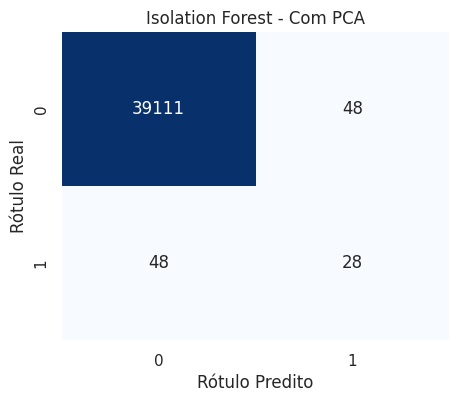

In [ ]:
print("--- Testando variações no Isolation Forest ---")
contaminations = [0.0017, 0.01] # 0.17% (Real) e 1% (Superestimado)
n_estimators_list = [50, 100]

for contam in contaminations:
    for n_est in n_estimators_list:
        iso_test = IsolationForest(n_estimators=n_est, max_samples=256, contamination=contam, random_state=42)
        iso_test.fit(X_train)
        preds = np.where(iso_test.predict(X_test) == -1, 1, 0)
        rec = recall_score(y_test, preds)
        prec = precision_score(y_test, preds)
        print(f"Estimadores: {n_est} | Contaminação: {contam} -> Precision: {prec:.2f} | Recall: {rec:.2f}")

# Modelo Final (Avaliação principal com e sem PCA)
def run_isolation_forest(X_train, X_test, y_test, contamination=0.0017, name="Sem PCA"):
    print(f"\n--- Isolation Forest Final ({name}) ---")

    # O modelo final usa a proporção real de fraudes para ser justo
    iso = IsolationForest(n_estimators=100, max_samples='auto', contamination=contamination, random_state=42)
    iso.fit(X_train)

    y_pred_iso = iso.predict(X_test)
    y_pred = np.where(y_pred_iso == -1, 1, 0) # Convertendo -1/1 para 1/0

    print(classification_report(y_test, y_pred))
    cm = plot_cm(y_test, y_pred, title=f"Isolation Forest - {name}")
    return cm

cm_iso_orig = run_isolation_forest(X_train, X_test, y_test, contamination=0.0017, name="Original")
cm_iso_pca = run_isolation_forest(X_pca_train, X_pca_test, y_test, contamination=0.0017, name="Com PCA")

### **Discussão: Isolation Forest**

*   **Sensibilidade ao parâmetro contamination:** O Isolation Forest é extremamente dependente desse hiperparâmetro. Como definimos `0.0017` (a taxa real de fraudes no dataset), ele limitou rigidamente o número de anomalias que poderia apontar. Se aumentássemos esse valor, pegaríamos mais fraudes, mas geraríamos uma avalanche de falsos positivos.
*   **Capacidade de detectar fraudes sem rótulos:** O modelo tem o grande mérito de isolar as anomalias baseando-se unicamente na estrutura dos dados, encontrando padrões "raros" sem nunca ter visto a coluna `Class` no treinamento.
*   **Limitações dessa abordagem:** O algoritmo não sabe o que é uma fraude real, ele apenas identifica o que é "estatisticamente diferente". Uma compra legítima, porém atípica (ex: comprar uma TV de madrugada), será barrada facilmente.
*   **Análise de Falsos Positivos e Falsos Negativos:**
    *   **FPs:** Aqui, os falsos positivos são comportamentos raros, mas perfeitamente legais.
    *   **FNs:** Fraudes que ocorrem dentro da normalidade (mesmo valor, mesma hora) não são isoladas pelas árvores, passando despercebidas.

## **Parte 4 — Comparação Crítica**

| Critério | Regressão Logística (Supervisionado) | Isolation Forest (Não Supervisionado) |
| :--- | :--- | :--- |
| **Desempenho (Métricas)** | Excelente Recall (capta bem as fraudes conhecidas), mas gera atrito com clientes (Baixa Precision se muito balanceado). | Baixa eficácia geral. Muito sensível à contaminação. |
| **Robustez ao Desbalanceamento** | Alta, desde que tratada via hiperparâmetros ou técnicas como SMOTE. | Inerente ao método, pois foi desenhado exatamente para buscar a minoria isolada nos dados. |
| **Interpretabilidade** | Altíssima. É possível extrair os coeficientes e explicar exatamente por que a transação foi negada. | Baixa. É difícil explicar para a área de negócios o caminho que a árvore não-supervisionada tomou. |
| **Dependência de Rótulos** | Total. Sem um histórico classificado por humanos, não existe modelo. | Nenhuma. Pode ser aplicado no "Dia 1" do lançamento de um novo cartão. |

**Análise Comparativa das Matrizes e Padrões de Erro:**
A Regressão Logística (especialmente a original sem PCA) apresentou um padrão de erro voltado para o *Falso Positivo* — ela acerta as fraudes (bom Recall), mas barra muitos bons clientes. O Isolation Forest erra bastante em *Falsos Negativos* — ele deixa passar fraudes sutis que se camuflam no volume de transações normais, mostrando que depender apenas da estrutura dos dados não é suficiente contra fraudadores sofisticados.

## **Parte 5 — Reflexão Final**

*   **Em que cenário usaria cada abordagem?**
    *   *Regressão Logística / Supervisionados:* Usaria no ambiente de produção consolidado (Core do negócio) onde há amplo histórico de fraudes. Ideal para cumprir normativas que exigem a "explicabilidade" da negação de crédito.
    *   *Isolation Forest:* Usaria em cenários de "Cold Start" (lançamento de um novo produto sem histórico) ou focado na descoberta de "Zero-Day Frauds" (novos golpes que os modelos supervisionados ainda não aprenderam).
*   **É possível combinar os dois métodos?**
    *   Sim! A melhor arquitetura na indústria utiliza os dois em conjunto. Podemos treinar um Isolation Forest e utilizar o *Anomaly Score* gerado por ele como uma nova coluna (feature) de entrada no dataset. A Regressão Logística então usará esse score não supervisionado somado aos dados reais para tomar a decisão final.
*   **Como esse problema se conecta com detecção de anomalias em outros domínios?**
    *   A natureza de procurar uma "agulha no palheiro" é idêntica à **medicina diagnóstica** (buscar células cancerígenas em milhões de pixels de uma ressonância), à **cibersegurança** (detectar um ataque de rede no meio do tráfego corporativo) e à **manutenção preditiva** na indústria (identificar a vibração sutil que antecede a quebra de um motor milionário). Em todos, os dados são desbalanceados e o custo do Falso Negativo é altíssimo.